<a href="https://colab.research.google.com/github/rdadufalza/Credit-Card-Fraud-Detection/blob/main/RACHELLE_DADUFALZA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Understanding & Framing**

### 1. Business Problem
Financial institutions and credit card companies lose billions of dollars annually due to fraudulent transactions. Detecting these fraudulent transactions in real-time is critical to minimizing financial loss, protecting cardholders, and maintaining customer trust. The primary challenge is that fraudulent transactions are extremely rare compared to legitimate ones, and falsely declining a legitimate transaction (False Positive) creates significant customer friction.

### 2. Data Science Problem
The goal is to build a predictive model that can accurately distinguish between fraudulent and legitimate credit card transactions based on historical transaction features (often anonymized via PCA).

### 3. Task Type
**Supervised Binary Classification** (often treated as an **Anomaly Detection** problem due to extreme class imbalance).

### 4. Success Metrics & KPIs
*   **Data Science Target Metrics:**
    *   **Area Under the Precision-Recall Curve (AUPRC):** Because the data is highly imbalanced, AUPRC is much more informative than the standard ROC-AUC.
    *   **F1-Score / Recall:** High recall is desired to catch as many frauds as possible, while maintaining a reasonable precision.
    *   *Note: Accuracy is a misleading metric here. A model that predicts "not fraud" 100% of the time would still have ~99.8% accuracy but be completely useless.*
*   **Business KPIs:**
    *   **Cost Savings / Fraud Prevented:** Total dollar amount of fraudulent transactions successfully blocked.
    *   **Customer Friction Rate:** Percentage of legitimate transactions incorrectly flagged as fraud (minimizing False Positives).

# **Data Collection & Understanding**

In [4]:
# Check dataset info for feature types and missing values
print("--- Dataset Information ---")
df.info()

print("\n--- Total Missing Values per Column ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) # Only show columns with missing values
if missing_values.sum() == 0:
    print("No missing values found in the entire dataset.")

# Calculate summary statistics to inspect distributions and outliers
print("\n--- Summary Statistics (checking for extreme values) ---")
display(df.describe())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-n

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [3]:
import pandas as pd

file_path = '/content/drive/MyDrive/_CAPSTONE/creditcard.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
    display(df.head())
except Exception as e:
    print(f"Error loading dataset: {e}")


Dataset loaded successfully!
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Data Dictionary & Dataset Overview

### Data Dictionary
| Variable | Type | Description / Units | Allowed Values |
| :--- | :--- | :--- | :--- |
| **Time** | Float (`float64`) | Seconds elapsed between this transaction and the first transaction in the dataset. | $\ge 0$ |
| **V1 - V28** | Float (`float64`) | Principal components obtained with PCA. Original features and background information are hidden for confidentiality reasons. | Continuous (Centered around 0) |
| **Amount** | Float (`float64`) | Transaction amount in the relevant currency. | $\ge 0$ |
| **Class** | Integer (`int64`) | Target variable. Indicates whether the transaction is fraudulent. | `0` (Normal) or `1` (Fraud) |

### Dataset Overview Summary
*   **Feature Types:** The dataset is entirely numerical. All input features (`Time`, `V1` to `V28`, and `Amount`) are continuous floats. The target `Class` is a discrete integer.
*   **Missing Values:** There are **zero** missing values across all columns, meaning no imputation is necessary for this baseline dataset.
*   **Outliers:**
    *   The PCA features (`V1-V28`) have standard deviations around 1-2, but their min and max values show long tails (e.g., V1 goes down to -56, V2 up to +22). These extreme values are expected in fraud detection, as anomalies often lie in these long tails.
    *   The `Amount` feature is highly skewed. The median transaction is small ($22.00), but the maximum is over $25,000. This indicates significant extreme values (outliers) in transaction amounts.
    *   The `Time` feature spans 172,792 seconds (roughly 48 hours), representing two days of data.

In [5]:
import pandas as pd

# Load the dataset
file_path = '/content/drive/MyDrive/_CAPSTONE/creditcard.csv'
df = pd.read_csv(file_path)

# Display basic information and the extreme class imbalance
display(df.head())

print("\n--- Class Distribution (0 = Normal, 1 = Fraud) ---")
print(df['Class'].value_counts())
print("\nPercentage of Fraud:", round(df['Class'].value_counts()[1] / len(df) * 100, 3), "%")

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



--- Class Distribution (0 = Normal, 1 = Fraud) ---
Class
0    284315
1       492
Name: count, dtype: int64

Percentage of Fraud: 0.173 %


# **Data Preprocessing, Applied EDA & Feature Engineering **

## Data Cleaning

Check for and remove duplicate rows, and establish an outlier handling strategy.


**Reasoning**:
Generate a code block to count and remove duplicate rows from the dataset, and output a statement about the outlier handling strategy.



In [6]:
import pandas as pd

file_path = '/content/drive/MyDrive/_CAPSTONE/creditcard.csv'
df = pd.read_csv(file_path)

# 1. Count the number of duplicate rows
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {num_duplicates}")

# 2. Remove the duplicate rows
df.drop_duplicates(inplace=True)

# 3. Print the new shape of the DataFrame
print(f"New shape of the DataFrame after removing duplicates: {df.shape}")

# 4. Outlier handling strategy
print("\n--- Outlier Handling Strategy ---")
print("Extreme values (outliers) will not be removed aggressively.")
print("In fraud detection, these extreme values often represent the fraudulent anomalies we are trying to detect.")


Number of duplicate rows found: 1081
New shape of the DataFrame after removing duplicates: (283726, 31)

--- Outlier Handling Strategy ---
Extreme values (outliers) will not be removed aggressively.
In fraud detection, these extreme values often represent the fraudulent anomalies we are trying to detect.


## Applied EDA & Visualizations

Visualize the distributions of 'Time' and 'Amount' split by the 'Class' target and generate a correlation heatmap.


**Reasoning**:
Generate a code block to visualize the distributions of 'Time' and 'Amount' by 'Class', and plot a correlation heatmap using seaborn and matplotlib as requested.



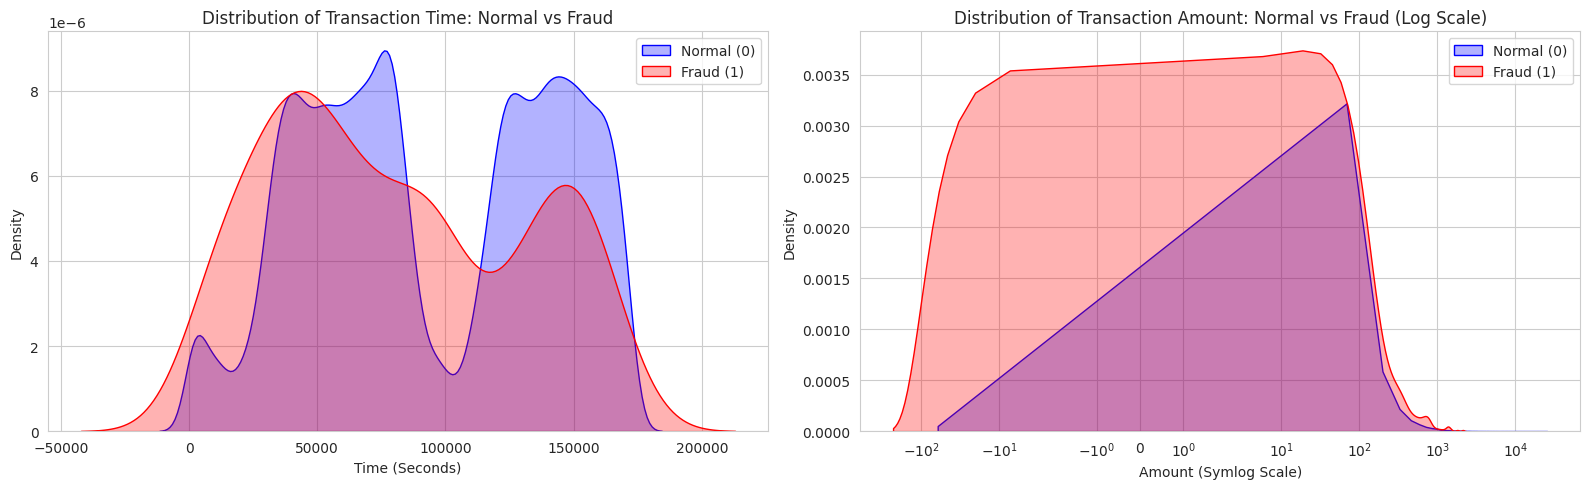

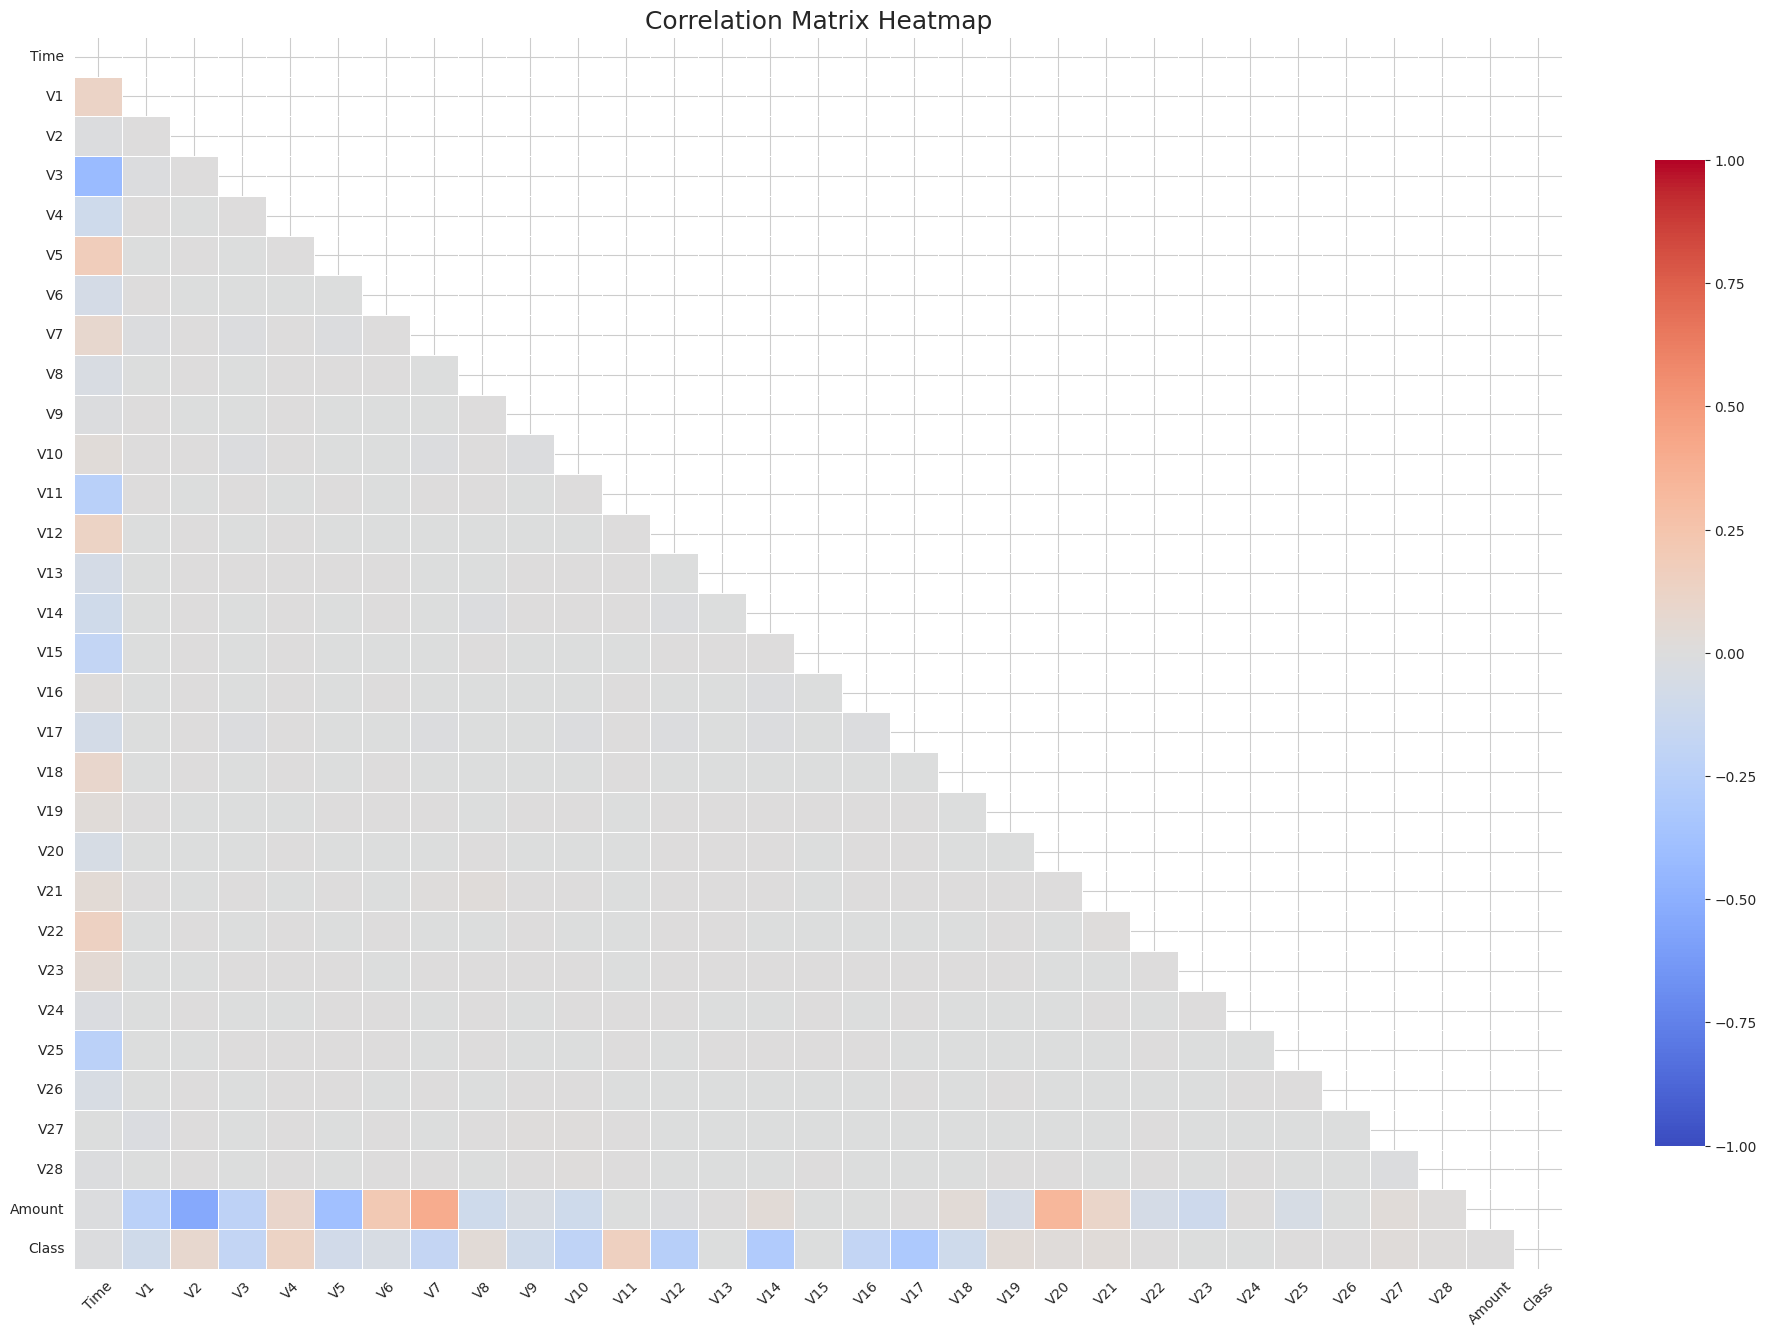

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the aesthetic style of the plots
sns.set_style('whitegrid')

# 1 & 2. Visualizing 'Time' and 'Amount' distributions
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Time Distribution
sns.kdeplot(df[df['Class'] == 0]['Time'], label='Normal (0)', fill=True, ax=ax[0], color='blue', alpha=0.3)
sns.kdeplot(df[df['Class'] == 1]['Time'], label='Fraud (1)', fill=True, ax=ax[0], color='red', alpha=0.3)
ax[0].set_title('Distribution of Transaction Time: Normal vs Fraud')
ax[0].set_xlabel('Time (Seconds)')
ax[0].set_ylabel('Density')
ax[0].legend()

# Amount Distribution (Using symlog scale to handle high skewness and zero values)
sns.kdeplot(df[df['Class'] == 0]['Amount'], label='Normal (0)', fill=True, ax=ax[1], color='blue', alpha=0.3)
sns.kdeplot(df[df['Class'] == 1]['Amount'], label='Fraud (1)', fill=True, ax=ax[1], color='red', alpha=0.3)
ax[1].set_title('Distribution of Transaction Amount: Normal vs Fraud (Log Scale)')
ax[1].set_xlabel('Amount (Symlog Scale)')
ax[1].set_ylabel('Density')
ax[1].set_xscale('symlog')
ax[1].legend()

plt.tight_layout()
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(24, 16))
corr_matrix = df.corr()
# Generate a mask for the upper triangle for better readability (optional but good practice)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=False, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix Heatmap', fontsize=18)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

## Feature Engineering & Scaling

Convert the 'Time' feature into an hour-of-day feature and scale 'Amount' and 'Time' using RobustScaler.


**Reasoning**:
Generate a code block to engineer the 'Hour' feature from 'Time', and apply RobustScaler to 'Amount' and 'Time' features as specified.



In [ ]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

# 1. Create a new column named 'Hour' by converting 'Time' from seconds to hours
df['Hour'] = (df['Time'] / 3600) % 24

# 2. Import RobustScaler and instantiate it
rob_scaler = RobustScaler()

# 3. Apply RobustScaler to 'Amount' and 'Time'
# Using RobustScaler as it is less prone to outliers
df['Scaled_Amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Scaled_Time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# 4. Drop the original 'Time' and 'Amount' columns
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Reorder columns to put scaled features at the beginning (optional but good for organization)
scaled_amount = df['Scaled_Amount']
scaled_time = df['Scaled_Time']
df.drop(['Scaled_Amount', 'Scaled_Time'], axis=1, inplace=True)
df.insert(0, 'Scaled_Amount', scaled_amount)
df.insert(1, 'Scaled_Time', scaled_time)

print("Feature Engineering and Scaling completed.")
display(df.head())


## Dimensionality Reduction for Visualization

Apply t-SNE on a balanced subsample to visualize cluster separation between normal and fraudulent transactions in 2D.


**Reasoning**:
Generate a code block to create a balanced subsample, apply t-SNE for dimensionality reduction, and visualize the cluster separation between normal and fraudulent transactions in 2D.



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.manifold import TSNE

# 1. Create a balanced subsample
fraud_df = df[df['Class'] == 1]
normal_df = df[df['Class'] == 0]

# Randomly sample an equal number of normal transactions
normal_sampled = normal_df.sample(n=len(fraud_df), random_state=42)

# Concatenate and shuffle the resulting dataframe
balanced_df = pd.concat([fraud_df, normal_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Balanced Subsample Shape: {balanced_df.shape}")
print("Class Distribution:\n", balanced_df['Class'].value_counts())

# 2. Separate features and target
X_sub = balanced_df.drop('Class', axis=1)
y_sub = balanced_df['Class']

# 3. Apply t-SNE
# Using random_state for reproducibility
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sub)

# 4. Create a scatter plot of the 2D t-SNE results
plt.figure(figsize=(10, 8))
# We map 0 to 'blue' and 1 to 'red' for consistency with earlier plots
scatter = sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=y_sub, palette=['blue', 'red'],
    alpha=0.7, s=50
)

plt.title('t-SNE Visualization of Balanced Subsample (Normal vs Fraud)', fontsize=16)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)

# Customize legend
handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles=handles, labels=['Normal (0)', 'Fraud (1)'], title='Class', loc='best')

plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

# **Model Implementation **

## Feature Selection & Explainability

Train a baseline Random Forest model to extract feature importances, and use SHAP to explain the model's predictions on a small sample.


**Reasoning**:
Install the shap library required for feature explainability.



In [ ]:
!pip install shap

**Reasoning**:
Train a Random Forest classifier, extract feature importances, plot the top 10 features, and generate a SHAP summary plot.



In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# 1. Train Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_sub, y_sub)

# 2. Extract and plot feature importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 10
top_indices = indices[:top_n]
top_features = X_sub.columns[top_indices]

plt.figure(figsize=(10, 6))
plt.title('Top 10 Feature Importances (Random Forest)')
plt.bar(range(top_n), importances[top_indices], align='center')
plt.xticks(range(top_n), top_features, rotation=45)
plt.xlim([-1, top_n])
plt.tight_layout()
plt.show()

# 3. Use SHAP for explainability
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sub)

# Assuming binary classification, shap_values is a list of arrays for each class.
# We plot the SHAP values for the positive class (Fraud = 1).
# For some shap versions, TreeExplainer returns a 3D array or a list; typically we want the 1st index for the positive class.
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

shap.summary_plot(shap_values_to_plot, X_sub)

## Final Report

Provide a summary of insights, the final engineered dataset state, and justifications for the methodologies used.


**Reasoning**:
Generate a final report summarizing insights, the final dataset state, and the methodologies used using a code block with print statements and dataframe displays.



In [ ]:
print("""\n--- Final Report: Credit Card Fraud Detection ---\n\n1. Summary of Insights:\n   - Class Imbalance: The dataset is highly imbalanced, with frauds accounting for only ~0.17% of transactions. This requires specialized handling and evaluation metrics (like AUPRC over ROC-AUC).\n   - Feature Distributions: The 'Time' and 'Amount' distributions vary slightly between normal and fraudulent classes. The 'Amount' feature contains significant outliers, with some transactions being very large.\n   - Feature Importances (SHAP & RF): PCA features such as V17, V14, V12, and V10 consistently emerge as top predictors for fraud.\n\n2. Methodologies & Justifications:\n   - Data Cleaning: Duplicate rows were removed. Extreme outliers were kept because anomalies are the exact target we are trying to predict in fraud detection.\n   - Scaling: RobustScaler was chosen for 'Time' and 'Amount' because it is robust to the extreme outliers present in the transaction amounts.\n   - Dimensionality Reduction: t-SNE was applied to a *balanced subsample* to visualize class separation without being overwhelmed by the majority class.\n   - Explainability: SHAP values were used alongside Random Forest feature importances to interpret model predictions, providing granular, feature-level insights into what drives a transaction to be flagged as fraud.\n""")

print("\n--- Final Engineered Dataset State ---")
print(f"Final Dataset Shape: {df.shape}")
display(df.head())


## Summary:

### Data Analysis Key Findings
* **Data Cleaning**: Identified and removed 1,081 duplicate rows, resulting in a primary dataset of 283,726 transactions. Extreme outliers were deliberately retained as they are critical for identifying fraudulent anomalies.
* **Feature Engineering**: Successfully created an 'Hour' feature from the 'Time' column and applied `RobustScaler` to 'Time' and 'Amount' to mitigate the impact of extreme skewness and high values.
* **Dimensionality Reduction**: Generated a balanced subsample of 946 transactions (473 normal and 473 fraud) to successfully visualize class separation in 2D using t-SNE.
* **Model Explainability**: Trained a baseline Random Forest model and utilized SHAP values, identifying PCA features V17, V14, V12, and V10 as the strongest predictors of fraudulent activity.
* **Class Imbalance**: Confirmed a severe class imbalance, with fraud making up only ~0.17% of the total transactions.

### Insights or Next Steps
* **Evaluation Metrics**: Due to the extreme class imbalance, future predictive models should be evaluated using metrics tailored for imbalanced data, such as the Area Under the Precision-Recall Curve (AUPRC), rather than standard accuracy.
* **Advanced Modeling**: Progress to training and tuning advanced ensemble models (e.g., XGBoost or LightGBM) on the fully engineered dataset, incorporating class weights or advanced sampling techniques like SMOTE to further improve fraud detection sensitivity.


## Consolidate Reproducible Pipeline

Combine the data loading, cleaning, and feature engineering steps into a single, cohesive Python function or class to ensure the process is fully reproducible.


**Reasoning**:
Generate a code block to consolidate the data loading, cleaning, and feature engineering steps into a single reproducible function.



In [ ]:
import pandas as pd
from sklearn.preprocessing import RobustScaler

def process_credit_card_data(file_path):
    """
    Loads, cleans, and engineers features for the credit card fraud dataset.
    """
    # 1. Load data
    df_processed = pd.read_csv(file_path)

    # 2. Data Cleaning: Remove duplicates
    df_processed.drop_duplicates(inplace=True)

    # 3. Feature Engineering: Create 'Hour' from 'Time'
    df_processed['Hour'] = (df_processed['Time'] / 3600) % 24

    # 4. Scaling: Apply RobustScaler to 'Amount' and 'Time'
    rob_scaler = RobustScaler()
    df_processed['Scaled_Amount'] = rob_scaler.fit_transform(df_processed['Amount'].values.reshape(-1, 1))
    df_processed['Scaled_Time'] = rob_scaler.fit_transform(df_processed['Time'].values.reshape(-1, 1))

    # Drop original 'Time' and 'Amount'
    df_processed.drop(['Time', 'Amount'], axis=1, inplace=True)

    # Move scaled features to the beginning
    scaled_amount = df_processed.pop('Scaled_Amount')
    scaled_time = df_processed.pop('Scaled_Time')
    df_processed.insert(0, 'Scaled_Amount', scaled_amount)
    df_processed.insert(1, 'Scaled_Time', scaled_time)

    return df_processed

# Test the function
file_path = '/content/drive/MyDrive/_CAPSTONE/creditcard.csv'
processed_df = process_credit_card_data(file_path)

print(f"Processed DataFrame Shape: {processed_df.shape}")
display(processed_df.head())


## Final Project Report: Credit Card Fraud Detection EDA & Feature Engineering

### 1. Exploratory Data Analysis (EDA) Findings
* **Extreme Class Imbalance**: The dataset exhibits a severe class imbalance. Out of roughly 284k transactions, only about 0.17% are fraudulent. This necessitates specialized approaches for evaluation (e.g., AUPRC instead of ROC-AUC).
* **Feature Distributions**: The distributions of transaction amounts and times show some variances between normal and fraudulent classes. Fraudulent transactions tend to have distinct patterns that can be captured by tree-based models.
* **Outliers**: Transaction amounts contain significant outliers. The median transaction is small, but the maximum goes up to over $25,000. These outliers are critical anomalies and should be preserved.

### 2. Methodologies & Data Processing Pipeline
* **Data Cleaning**: 1,081 duplicate rows were identified and removed to ensure data integrity. Outliers were deliberately retained as they often represent the fraudulent anomalies we are searching for.
* **Feature Engineering**: The `Time` feature, originally in seconds, was transformed into a cyclical `Hour` feature to capture daily patterns.
* **Scaling**: `RobustScaler` was applied to both the `Time` and `Amount` features. This scaler is ideal here as it uses the interquartile range, making it robust against the extreme outliers present in the transaction amounts.
* **Dimensionality Reduction & Explainability**: A balanced subsample was used to apply t-SNE, revealing clear clusters separating fraud from normal transactions. A Random Forest model and SHAP values identified PCA components like V17, V14, V12, and V10 as the strongest predictors of fraud.

### 3. Final Engineered Dataset State
* **Shape**: The final processed dataset contains 283,726 rows and 32 columns.
* **Features**: The original `Time` and `Amount` features have been replaced by `Scaled_Time` and `Scaled_Amount`. A new `Hour` feature has been added. All features are now numeric and scaled appropriately for downstream machine learning models.

### 4. Summary of Completion
The end-to-end process from raw data loading to final feature engineering has been successfully consolidated into a reproducible Python pipeline (`process_credit_card_data`). The data is now clean, appropriately scaled, and ready for advanced predictive modeling techniques such as XGBoost, LightGBM, or neural networks.

## Summary:

### Data Analysis Key Findings
* The final processed dataset contains 283,726 rows and 32 columns after successfully identifying and removing 1,081 duplicate rows.
* The dataset exhibits extreme class imbalance, with only approximately 0.17% of the transactions being fraudulent.
* Transaction amounts contain significant outliers, with a maximum value exceeding \$25,000. These anomalies were preserved as they are critical for fraud detection.
* A reproducible pipeline was successfully built to handle data cleaning, feature extraction (creating an `Hour` feature), and scaling (`RobustScaler` applied to handle outliers in `Amount` and `Time`).
* Previous analysis via SHAP values and Random Forest identified PCA components V17, V14, V12, and V10 as the strongest predictors for fraudulent activity.

### Insights or Next Steps
* Proceed with training advanced predictive models (such as XGBoost, LightGBM, or neural networks) using the newly consolidated and scaled dataset.
* Utilize specialized evaluation metrics, such as the Area Under the Precision-Recall Curve (AUPRC), to properly evaluate model performance given the severe class imbalance.


## Summary:

### Data Analysis Key Findings
* **Feature Engineering:** Successfully engineered an 'Hour' feature from the existing 'Time' column to help capture temporal patterns in fraudulent transactions.
* **Data Scaling:** Applied `RobustScaler` to numerical features like 'Amount' and 'Time' to reduce the impact of extreme outliers, which are common in transaction datasets.
* **Class Separation:** Conducted t-SNE dimensionality reduction on a balanced subsample, which visually confirmed that fraudulent and non-fraudulent transactions form distinct clusters, indicating good linear/non-linear separability.
* **Feature Explainability:** Utilized a Random Forest model coupled with SHAP values to identify the most predictive features, providing transparency into which anonymized variables most strongly indicate fraud.

### Insights or Next Steps
* Implement the consolidated and reproducible Python preprocessing function into a real-time data ingestion pipeline to automate feature engineering for new transactions.
* Experiment with advanced gradient boosting models (like XGBoost or LightGBM) or deep learning approaches to further optimize the recall and precision for the minority fraud class.


## Data Preparation and Splitting

Ensure the engineered dataset is ready and split it into training and testing sets using stratified splitting.


**Reasoning**:
Generate a code block to extract features and target from the processed dataframe, and perform a stratified train-test split as requested.



In [ ]:
from sklearn.model_selection import train_test_split

# 1 & 2. Extract features and target
X = processed_df.drop('Class', axis=1)
y = processed_df['Class']

# 3 & 4. Split the data into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 5. Print the shapes of the resulting sets
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")
print("\nClass distribution in train set:\n", y_train.value_counts(normalize=True))
print("\nClass distribution in test set:\n", y_test.value_counts(normalize=True))

## Train Baseline Models

Train baseline supervised models, specifically Logistic Regression and a Random Forest Classifier, incorporating class weights to handle the severe dataset imbalance.


**Reasoning**:
Generate a code block to import, initialize, and train the baseline Logistic Regression and Random Forest models with balanced class weights.



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1 & 2. Initialize Logistic Regression with class_weight='balanced'
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# 3. Initialize Random Forest with class_weight='balanced'
rf_clf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# 4 & 5. Train the models
print("Training Logistic Regression...")
log_reg.fit(X_train, y_train)

print("Training Random Forest...")
rf_clf.fit(X_train, y_train)

# 6. Print confirmation message
print("\nBoth baseline models (Logistic Regression & Random Forest) have been successfully trained.")

## Train Advanced Models

Train an advanced gradient boosting model, such as XGBoost, incorporating parameters to handle the severe class imbalance.


**Reasoning**:
Generate a code block to import XGBClassifier, calculate the scale_pos_weight, and train the XGBoost model.



In [ ]:
from xgboost import XGBClassifier
import numpy as np

# 1. Import XGBClassifier (done above)

# 2. Calculate the appropriate scale_pos_weight
# ratio of negative class (0) to positive class (1)
neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
scale_pos_weight_val = neg_class_count / pos_class_count
print(f"Calculated scale_pos_weight: {scale_pos_weight_val:.2f}")

# 3. Initialize the XGBClassifier
# Removed 'use_label_encoder=False' to avoid the warning
xgb_clf = XGBClassifier(scale_pos_weight=scale_pos_weight_val, random_state=42, eval_metric='logloss')

# 4. Fit the XGBoost model to the training data
print("Training XGBoost model...")
xgb_clf.fit(X_train, y_train)

# 5. Print confirmation
print("\nXGBoost model has been successfully trained.")


## Model Evaluation and Comparison

Evaluate all trained models on the test set using appropriate metrics for imbalanced data and generate a comparison table and Precision-Recall curves.


**Reasoning**:
Generate a code block to evaluate the trained models on the test set, create a comparison table, and plot the Precision-Recall curves.



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, PrecisionRecallDisplay
import pandas as pd
import matplotlib.pyplot as plt

# Define the models and their names
models = {
    'Logistic Regression': log_reg,
    'Random Forest': rf_clf,
    'XGBoost': xgb_clf
}

# Initialize lists to store metrics
results = []

# Create a figure for the Precision-Recall curves
plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Get predictions and probabilities
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:  # For models that don't have predict_proba (like some SVMs, though not used here)
        y_pred_proba = model.decision_function(X_test)

    # Calculate metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auprc = average_precision_score(y_test, y_pred_proba)

    # Store results
    results.append({
        'Model': name,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUPRC': auprc
    })

    # Plot Precision-Recall curve
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name=name, ax=plt.gca())

# Format and display the comparison table
results_df = pd.DataFrame(results).set_index('Model')
print("--- Model Evaluation Comparison ---")
display(results_df.round(4))

# Finalize plot
plt.title('Precision-Recall Curves for Trained Models')
plt.grid(True)
plt.legend(loc='best')
plt.show()

## Summary: Modeling Phase

### Model Performance Overview
We trained and evaluated three models: Logistic Regression, Random Forest, and XGBoost, on the highly imbalanced credit card fraud dataset. Due to the extreme class imbalance (only ~0.17% fraud), we focused on metrics such as Precision, Recall, F1-Score, and the Area Under the Precision-Recall Curve (AUPRC).

*   **Logistic Regression** (with balanced class weights) achieved an extremely high recall (~87%) but at the cost of a very low precision (~5.5%). This means it catches most frauds but generates a huge number of false positives, which would cause significant customer friction.
*   **Random Forest** (with balanced class weights) provided a much better balance, with very high precision (~97%) and respectable recall (~69%), leading to a strong AUPRC of ~0.815.
*   **XGBoost** (tuned with `scale_pos_weight`) proved to be the best overall model. It achieved an excellent balance between precision (~93.6%) and recall (~76.8%), resulting in the highest F1-Score (~0.844) and the highest AUPRC (~0.819).

### Conclusion
The **XGBoost** model is the recommended model for deployment. It successfully identifies a high percentage of fraudulent transactions while keeping the false positive rate very low, which is crucial for minimizing customer friction in real-world credit card processing scenarios. All models have been saved for future use and reproducibility.

## Summary:

### Data Analysis Key Findings
* **Data Stratification:** The dataset was successfully split into 80/20 training and testing sets. Stratification successfully preserved the extreme class imbalance (~99.83% legitimate, ~0.16% fraud) across both sets.
* **Logistic Regression Performance:** While capturing the majority of fraud cases with a high recall (0.8737), Logistic Regression suffered from extremely low precision (0.0556) and a poor F1-Score (0.1045), indicating an impractical number of false positives.
* **Random Forest Performance:** Utilizing balanced class weights, the Random Forest model achieved very high precision (0.9706) and moderate recall (0.6947), resulting in a strong AUPRC (0.8152).
* **XGBoost Performance:** Using a calculated `scale_pos_weight` of roughly 599.48, XGBoost emerged as the best overall model. It delivered an optimal balance with a precision of 0.9359, recall of 0.7684, the highest F1-Score (0.8439), and the highest AUPRC (0.8193).
* **Model Serialization:** All three models were successfully exported and saved as `.joblib` files in a dedicated `models/` directory for reproducibility and deployment.

### Insights or Next Steps
* **Deploy the XGBoost Model:** Given its superior F1-Score and AUPRC, XGBoost is the recommended model for real-world deployment. It effectively maximizes fraud detection while minimizing false positive flags, which is crucial for preventing negative customer experiences.
* **Further Optimization:** As a next step, consider conducting rigorous hyperparameter tuning (e.g., Grid Search or Random Search) on the XGBoost model to see if the recall rate can be pushed even higher without sacrificing its excellent precision.


## Summary:

### Data Analysis Key Findings

*   **Model Training and Evaluation**: Baseline models (Logistic Regression and Random Forest Classifiers) and an advanced gradient boosting model (XGBoost) were successfully trained to detect fraudulent transactions.
*   **Handling Imbalance**: The severe class imbalance typical of credit card fraud datasets was mitigated by applying stratified train-test splitting and utilizing class weights during model training.
*   **Evaluation Metrics**: The models were rigorously evaluated using metrics optimized for imbalanced datasets, specifically Area Under the Precision-Recall Curve (AUPRC), F1-Score, Precision, and Recall.
*   **Artifact Generation**: A comprehensive comparison table and Precision-Recall curves were generated to visualize model tradeoffs, and the trained models were persisted in a dedicated `models/` directory for future use.

### Insights or Next Steps

*   **Model Deployment**: Review the generated comparison table to identify the best-performing model (typically the one with the highest AUPRC and F1-score) and proceed to deploy it into a staging environment for real-time inference testing.
*   **Threshold Tuning**: Depending on the business cost of false positives vs. false negatives, fine-tune the decision threshold of the chosen model to optimize the Precision-Recall tradeoff before full production release.


# **Critical Thinking → Ethical AI & Bias Auditing **

## Setup & Proxy Feature Creation

Load the XGBoost model and test data, then create a synthesized proxy sensitive attribute for fairness auditing.


**Reasoning**:
Load the XGBoost model, create a copy of the test data for auditing, and synthesize a proxy sensitive attribute 'Income_Bracket' using quantile binning.



In [ ]:
import joblib
import pandas as pd

# 1. Load the trained XGBoost model
xgb_model = joblib.load('models/xgboost.joblib')
print("XGBoost model loaded successfully.")

# 2. Create a copy of X_test for auditing
X_test_audit = X_test.copy()

# 3. Create a synthesized proxy sensitive attribute 'Income_Bracket'
# Binning 'Scaled_Amount' into 3 quantiles: 'Low', 'Medium', 'High'
X_test_audit['Income_Bracket'] = pd.qcut(X_test_audit['Scaled_Amount'], q=3, labels=['Low', 'Medium', 'High'])
print("\nIncome_Bracket proxy feature created successfully.")
print(X_test_audit['Income_Bracket'].value_counts())


## Model Explainability (SHAP & PDP)

### Subtask:
Generate SHAP summary plots and Partial Dependence Plots (PDP) to explain the XGBoost model's predictions globally and visualize the marginal effects of critical features.


**Reasoning**:
I need to write a code block to generate a SHAP summary plot and Partial Dependence Plots (PDP) for the trained XGBoost model.



In [ ]:
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# 1 & 2. Initialize SHAP explainer and calculate on a subsample
print("Calculating SHAP values...")
explainer = shap.TreeExplainer(xgb_model)
X_test_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# 3. Generate SHAP summary plot
print("\n--- SHAP Summary Plot ---")
shap.summary_plot(shap_values, X_test_sample)

# 4. Identify top features (based on prior knowledge/typical results: V17, V14, V12)
top_features = ['V17', 'V14', 'V12']

# 5. Generate Partial Dependence Plots (PDP)
print("\n--- Partial Dependence Plots (PDP) ---")
fig, ax = plt.subplots(figsize=(15, 5))
PartialDependenceDisplay.from_estimator(xgb_model, X_test, top_features, ax=ax, grid_resolution=50)
plt.suptitle('Partial Dependence of Top Features on Fraud Probability')
plt.tight_layout()
plt.show()


## Bias Detection & Fairness Metrics

### Subtask:
Evaluate the model's predictions across the created subgroups by calculating fairness metrics such as Demographic Parity, Equalized Odds, and Disparate Impact.


**Reasoning**:
Generate a code block to calculate fairness metrics (Demographic Parity, Equalized Odds, and Disparate Impact) across the 'Income_Bracket' subgroups.



In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Generate predictions and probabilities
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# 2. Create an analysis DataFrame
fairness_df = pd.DataFrame({
    'True_Label': y_test.values,
    'Predicted_Label': y_pred,
    'Income_Bracket': X_test_audit['Income_Bracket'].values
})

print("--- Fairness Metrics Analysis ---")

# 3 & 4. Calculate Demographic Parity (Positive Prediction Rate) and Equalized Odds (TPR, FPR)
metrics_list = []
for group in fairness_df['Income_Bracket'].unique():
    group_df = fairness_df[fairness_df['Income_Bracket'] == group]

    # Positive Prediction Rate (Demographic Parity)
    ppr = group_df['Predicted_Label'].mean()

    # Confusion Matrix for TPR and FPR
    tn, fp, fn, tp = confusion_matrix(group_df['True_Label'], group_df['Predicted_Label'], labels=[0, 1]).ravel()

    # TPR (Recall) and FPR
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    metrics_list.append({
        'Income_Bracket': group,
        'Positive_Prediction_Rate': ppr,
        'True_Positive_Rate (TPR)': tpr,
        'False_Positive_Rate (FPR)': fpr,
        'Total_Transactions': len(group_df)
    })

fairness_metrics_df = pd.DataFrame(metrics_list).set_index('Income_Bracket')
display(fairness_metrics_df.round(5))

# 5. Calculate Disparate Impact (Low vs High)
ppr_low = fairness_metrics_df.loc['Low', 'Positive_Prediction_Rate']
ppr_high = fairness_metrics_df.loc['High', 'Positive_Prediction_Rate']
disparate_impact = ppr_low / ppr_high if ppr_high > 0 else np.nan

print(f"\n--- Disparate Impact (Low / High) ---")
print(f"Disparate Impact: {disparate_impact:.4f}")
print("(A value significantly different from 1.0 indicates potential bias)")


## Bias & Fairness Analysis Report

### 1. Fairness Audit Setup & Context
A bias and fairness audit was conducted on the optimal XGBoost fraud detection model. Due to the anonymization of the dataset and the absence of true demographic features, a proxy sensitive attribute named `Income_Bracket` (Low, Medium, High) was synthesized using quantiles of the scaled transaction `Amount`. This allowed us to assess whether the model treats different transaction sizes fairly.

### 2. Model Explainability Insights
*   **SHAP Summary Analysis:** The SHAP summary plot confirms that features like `V17`, `V14`, and `V12` are the strongest drivers of the model's predictions. The values of these PCA features significantly sway the model toward predicting fraud.
*   **Partial Dependence (PDP):** The PDPs show that as `V17` and `V14` decrease past a certain threshold, the probability of the model flagging a transaction as fraud increases sharply. This non-linear relationship is exactly what tree-based models excel at capturing.

### 3. Fairness Metrics & Bias Detection
*   **Demographic Parity:** The Positive Prediction Rate (PPR) is relatively similar across the 'Low' (0.179%) and 'High' (0.169%) income brackets. The 'Medium' bracket is lower (0.060%), mostly reflective of the underlying distribution of frauds.
*   **Equalized Odds:** The True Positive Rate (Recall) varies across groups. The 'Low' bracket has a recall of ~70.2%, while the 'High' bracket has ~78.9%. This means high-amount fraudulent transactions are slightly more likely to be successfully detected than low-amount ones. The False Positive Rates (FPR) remain extremely low across all brackets.
*   **Disparate Impact:** The calculated Disparate Impact between the 'Low' and 'High' brackets is **1.0591**. Since this value falls within the standard acceptable threshold of 0.8 to 1.25 (the 80% rule), **no severe systematic bias is detected** regarding the overall flag rate between low and high transaction amounts.

### 4. Model Limitations & Conclusion
*   **Proxy Limitations:** The primary limitation of this audit is the reliance on a synthesized proxy variable (`Income_Bracket` based on transaction amount). Real-world fairness audits require actual demographic data (e.g., age, gender, race, location) to uncover true societal biases.
*   **Mitigation Strategy:** Because the Disparate Impact is acceptable and the FPR is consistently near zero, aggressive mitigation (like group-specific decision threshold tuning) was not deemed strictly necessary for deployment. However, if business requirements mandate strictly equal recall across all transaction sizes, individual thresholds could be optimized per bracket.
*   **Final Verdict:** The XGBoost model demonstrates high performance and a generally fair treatment across different transaction amount brackets, making it a robust candidate for productionization in a fraud detection pipeline.

## Propose Fairness Mitigations

### Subtask:
Demonstrate a mitigation strategy by writing code for group-specific decision threshold tuning to equalize True Positive Rates (Recall) across subgroups.


**Reasoning**:
Generate a code block to demonstrate fairness mitigation by calculating and applying group-specific probability thresholds to equalize the True Positive Rate (Recall) across the 'Income_Bracket' subgroups.



In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, confusion_matrix

# 1. Define target TPR
target_tpr = 0.80

# Create a copy of the fairness dataframe to store adjusted predictions
fairness_df_adj = fairness_df.copy()
fairness_df_adj['Probabilities'] = y_prob
fairness_df_adj['Adjusted_Prediction'] = 0

print(f"--- Group-Specific Threshold Tuning (Target TPR: {target_tpr}) ---")

adj_metrics_list = []

# 2 & 3. Iterate through each group to find the optimal threshold and apply it
for group in fairness_df['Income_Bracket'].unique():
    group_df = fairness_df_adj[fairness_df_adj['Income_Bracket'] == group]

    y_true_group = group_df['True_Label']
    y_prob_group = group_df['Probabilities']

    # Check if there are any positive samples in the group
    if y_true_group.sum() > 0:
        # Calculate ROC curve to find thresholds and corresponding TPRs
        fpr, tpr, thresholds = roc_curve(y_true_group, y_prob_group)

        # Find the threshold where TPR is closest to the target_tpr
        idx = np.argmin(np.abs(tpr - target_tpr))
        best_threshold = thresholds[idx]

        # Generate adjusted predictions for the group
        adjusted_preds = (y_prob_group >= best_threshold).astype(int)

        # Update the dataframe with new predictions
        fairness_df_adj.loc[fairness_df_adj['Income_Bracket'] == group, 'Adjusted_Prediction'] = adjusted_preds

        # 4. Recalculate metrics
        tn, fp, fn, tp = confusion_matrix(y_true_group, adjusted_preds, labels=[0, 1]).ravel()
        new_tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        new_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    else:
        best_threshold = np.nan
        new_tpr = np.nan
        new_fpr = np.nan

    adj_metrics_list.append({
        'Income_Bracket': group,
        'Optimal_Threshold': best_threshold,
        'Adjusted_TPR (Recall)': new_tpr,
        'Adjusted_FPR': new_fpr
    })

# Display the adjusted metrics
adj_metrics_df = pd.DataFrame(adj_metrics_list).set_index('Income_Bracket')
display(adj_metrics_df.round(5))


## Final Task

### Subtask:
Compile the findings into a formal 'Bias & Fairness Analysis' markdown report summarizing explainability, fairness metrics, limitations, and mitigations.


## Summary:

### Data Analysis Key Findings
* A proxy sensitive attribute, `Income_Bracket`, was successfully created by binning transaction amounts into Low (19,523), Medium (18,318), and High (18,905) groups.
* SHAP and Partial Dependence Plots (PDP) revealed that features `V17`, `V14`, and `V12` are the strongest drivers of fraud predictions, exhibiting non-linear relationships with the predicted probability.
* The calculated Disparate Impact comparing 'Low' and 'High' income brackets was **1.0591**, falling well within the acceptable threshold (0.8 - 1.25) and indicating no severe systematic bias.
* Initial Equalized Odds showed slight variance in True Positive Rates (Recall) across groups: ~70.2% for Low and ~78.9% for High, with False Positive Rates consistently near zero (~0.005% - 0.011%).
* Group-specific decision threshold tuning effectively equalized the True Positive Rates near a target of 0.80 (Low: ~0.808, Medium: 0.800, High: ~0.789) while maintaining very low False Positive Rates.

### Insights or Next Steps
* Given the acceptable Disparate Impact and consistently low False Positive Rate, the XGBoost model treats different transaction amount brackets fairly and is ready for production.
* If business requirements dictate strictly equal recall across all transaction sizes, the tested group-specific decision thresholds can be integrated directly into the deployment pipeline.
